# FuzzyDTree Classifier Demo

Decision boundary comparison inspired by sklearn's
[classifier comparison](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).

We compare **FuzzyDTree** (compact-support fuzzy splits, logit-MSE/Gini split objective)
against standard classifiers on three synthetic 2D datasets:
moons, circles, and linearly separable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from fuzzydtree import FuzzyTreeClassifier

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

## Datasets

In [2]:
# Three 2D datasets
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=0)
X_circles, y_circles = make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=1)
X_lin, y_lin = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                   n_informative=2, random_state=2,
                                   n_clusters_per_class=1)
# Add a bit of noise to the linear dataset
rng = np.random.RandomState(2)
X_lin += 2 * rng.uniform(size=X_lin.shape)

datasets = [
    ('Moons',    X_moons,   y_moons),
    ('Circles',  X_circles, y_circles),
    ('Linear',   X_lin,     y_lin),
]

## Classifiers

In [3]:
classifiers = [
    ('FuzzyDTree (d=5)',  FuzzyTreeClassifier(max_depth=5)),
    ('FuzzyDTree (d=10)', FuzzyTreeClassifier(max_depth=10)),
    ('DecisionTree',     DecisionTreeClassifier(max_depth=5)),
    ('Random Forest',    RandomForestClassifier(max_depth=5, n_estimators=50, random_state=0)),
    ('kNN (k=5)',        KNeighborsClassifier(n_neighbors=5)),
    ('SVM (RBF)',        SVC(gamma='auto', probability=True)),
]

## Decision boundaries

Each column is a dataset, each row is a classifier.
Background colour shows the predicted class; the colour intensity reflects `predict_proba`.
The **fuzzy tree** should produce noticeably **smoother boundaries** than the hard decision tree.

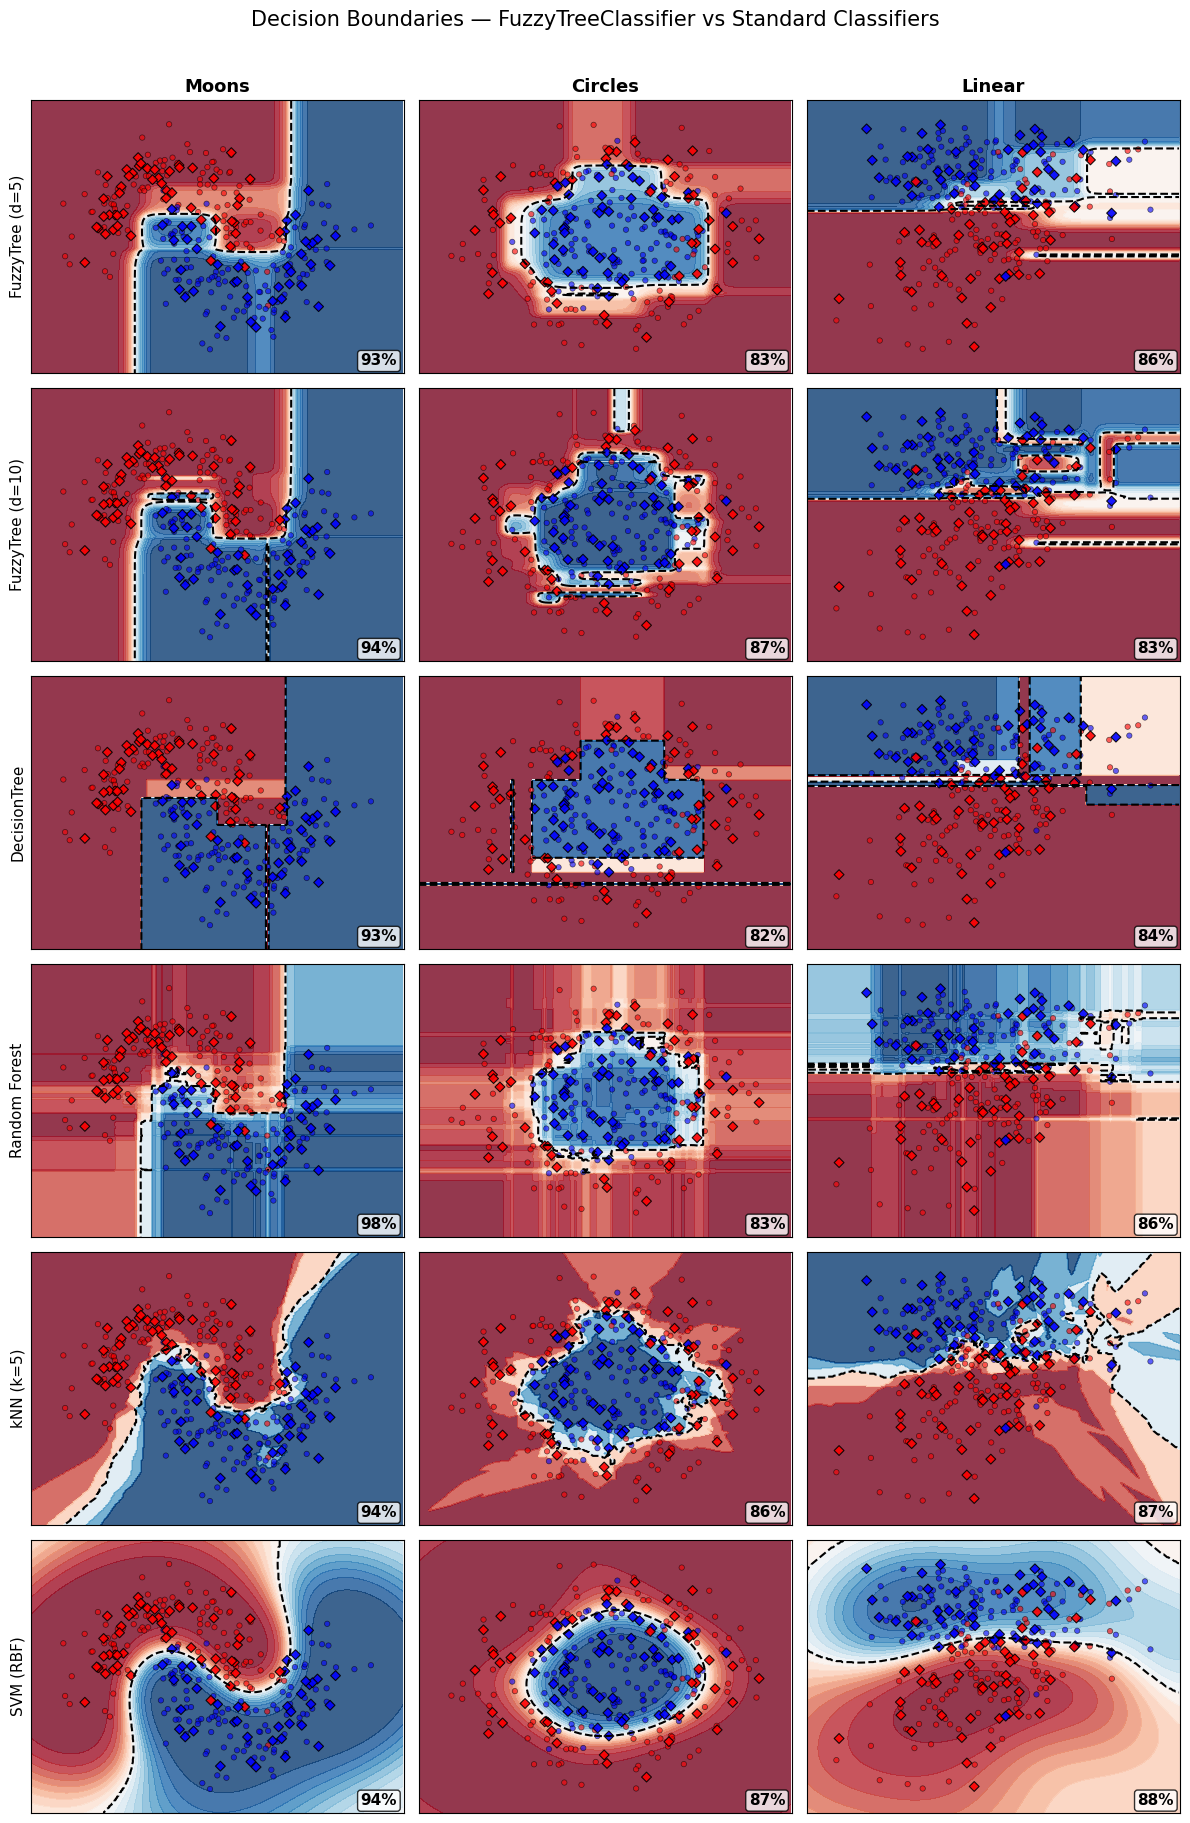

In [4]:
cm_bg = ListedColormap(['#FFAAAA', '#AAAAFF'])
cm_pts = ListedColormap(['#FF0000', '#0000FF'])
h = 0.02  # mesh step

n_cls = len(classifiers)
n_ds = len(datasets)

fig, axes = plt.subplots(n_cls, n_ds, figsize=(4 * n_ds, 3 * n_cls))

for col, (ds_name, X_raw, y_raw) in enumerate(datasets):
    # Scale and split
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y_raw, test_size=0.3, random_state=42)

    # Mesh for decision boundary
    x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
    y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    mesh_pts = np.c_[xx.ravel(), yy.ravel()]

    for row, (clf_name, clf_template) in enumerate(classifiers):
        ax = axes[row, col]

        # Clone the classifier for each dataset
        from sklearn.base import clone
        try:
            clf = clone(clf_template)
        except Exception:
            clf = clf_template.__class__(**clf_template.get_params())
        clf.fit(X_tr, y_tr)

        # Predict probabilities on mesh
        if hasattr(clf, 'predict_proba'):
            Z = clf.predict_proba(mesh_pts)[:, 1]
        else:
            Z = clf.predict(mesh_pts).astype(float)
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21),
                    cmap='RdBu', alpha=0.8)
        ax.contour(xx, yy, Z, levels=[0.5], colors='k',
                   linewidths=1.5, linestyles='--')

        # Training and test points
        ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cm_pts,
                   edgecolors='k', s=15, linewidths=0.5, alpha=0.6)
        ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap=cm_pts,
                   edgecolors='k', s=25, linewidths=0.8, marker='D', alpha=0.9)

        score = clf.score(X_te, y_te)
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(x_max - 0.1, y_min + 0.1, f'{score:.0%}',
                fontsize=11, fontweight='bold', ha='right', va='bottom',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

        if row == 0:
            ax.set_title(ds_name, fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(clf_name, fontsize=11)

fig.suptitle('Decision Boundaries \u2014 FuzzyDTree vs Standard Classifiers',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Accuracy summary table

In [5]:
from sklearn.base import clone

print(f'{"Classifier":<20}', end='')
for ds_name, _, _ in datasets:
    print(f' {ds_name:>10}', end='')
print(f' {"Average":>10}')
print('-' * (20 + 10 * (n_ds + 1)))

for clf_name, clf_template in classifiers:
    scores = []
    print(f'{clf_name:<20}', end='')
    for ds_name, X_raw, y_raw in datasets:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_raw)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_scaled, y_raw, test_size=0.3, random_state=42)
        try:
            clf = clone(clf_template)
        except Exception:
            clf = clf_template.__class__(**clf_template.get_params())
        clf.fit(X_tr, y_tr)
        s = clf.score(X_te, y_te)
        scores.append(s)
        print(f' {s:>10.1%}', end='')
    print(f' {np.mean(scores):>10.1%}')

Classifier                Moons    Circles     Linear    Average
------------------------------------------------------------
FuzzyDTree (d=5)           93.3%      83.3%      85.6%      87.4%
FuzzyDTree (d=10)          94.4%      86.7%      83.3%      88.1%
DecisionTree              93.3%      83.3%      84.4%      87.0%
Random Forest             97.8%      83.3%      85.6%      88.9%
kNN (k=5)                 94.4%      85.6%      86.7%      88.9%
SVM (RBF)                 94.4%      86.7%      87.8%      89.6%


## Predict-proba heatmap (Moons dataset)

Side-by-side comparison of how **FuzzyDTree** vs **DecisionTreeClassifier**
assign class-1 probability across the feature space.
The fuzzy tree produces a smooth gradient; the hard tree produces sharp rectangular steps.

C:\Users\guyko\AppData\Local\Temp\ipykernel_28864\1797574527.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


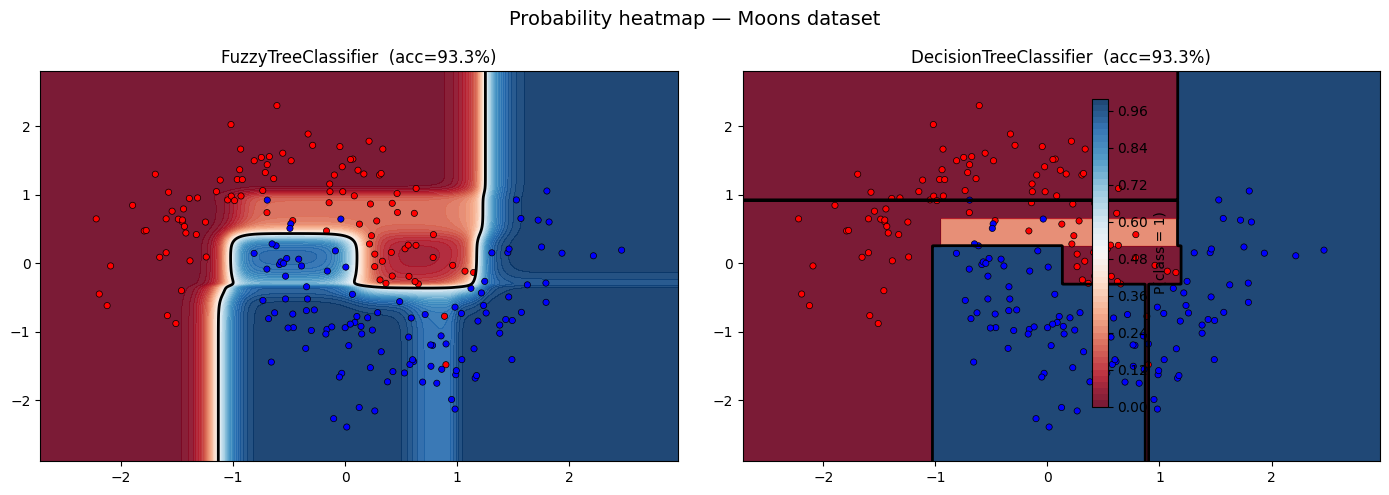

In [6]:
scaler = StandardScaler()
X_m = scaler.fit_transform(X_moons)
X_tr, X_te, y_tr, y_te = train_test_split(X_m, y_moons, test_size=0.3, random_state=42)

x_min, x_max = X_m[:, 0].min() - 0.5, X_m[:, 0].max() + 0.5
y_min, y_max = X_m[:, 1].min() - 0.5, X_m[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
mesh = np.c_[xx.ravel(), yy.ravel()]

fuzzy_clf = FuzzyTreeClassifier(max_depth=5)
fuzzy_clf.fit(X_tr, y_tr)

hard_clf = DecisionTreeClassifier(max_depth=5)
hard_clf.fit(X_tr, y_tr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, clf, title in [(ax1, fuzzy_clf, 'FuzzyDTree'),
                        (ax2, hard_clf, 'DecisionTreeClassifier')]:
    Z = clf.predict_proba(mesh)[:, 1].reshape(xx.shape)
    im = ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 51),
                     cmap='RdBu', alpha=0.9)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cm_pts,
              edgecolors='k', s=20, linewidths=0.5)
    score = clf.score(X_te, y_te)
    ax.set_title(f'{title}  (acc={score:.1%})', fontsize=12)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.colorbar(im, ax=[ax1, ax2], label='P(class = 1)', shrink=0.8)
fig.suptitle('Probability heatmap \u2014 Moons dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Multiclass example

Three-class classification with coloured decision regions.

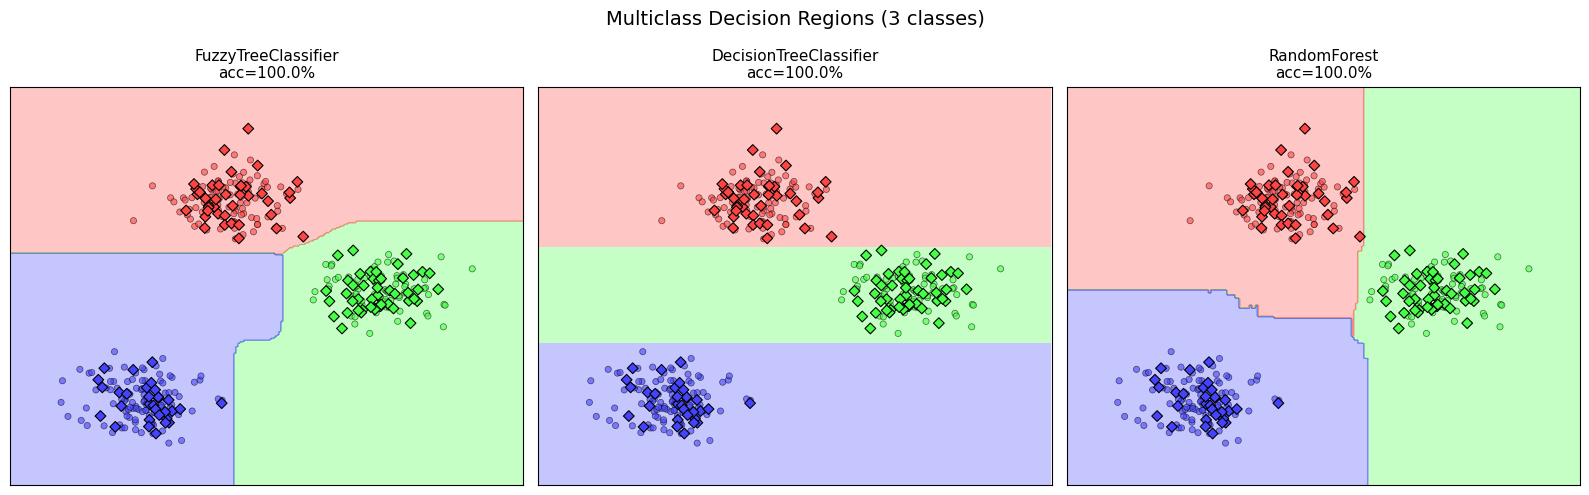

In [7]:
from sklearn.datasets import make_blobs

X_blobs, y_blobs = make_blobs(n_samples=400, centers=3, n_features=2,
                              cluster_std=1.5, random_state=42)
scaler = StandardScaler()
X_b = scaler.fit_transform(X_blobs)
X_tr, X_te, y_tr, y_te = train_test_split(X_b, y_blobs, test_size=0.3, random_state=42)

x_min, x_max = X_b[:, 0].min() - 0.5, X_b[:, 0].max() + 0.5
y_min, y_max = X_b[:, 1].min() - 0.5, X_b[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
mesh = np.c_[xx.ravel(), yy.ravel()]

cm3 = ListedColormap(['#FF4444', '#44FF44', '#4444FF'])

multi_clfs = [
    ('FuzzyDTree',    FuzzyTreeClassifier(max_depth=6)),
    ('DecisionTreeClassifier', DecisionTreeClassifier(max_depth=6)),
    ('RandomForest',           RandomForestClassifier(max_depth=6, n_estimators=50, random_state=0)),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, clf) in zip(axes, multi_clfs):
    clf.fit(X_tr, y_tr)
    Z = clf.predict(mesh).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cm3, alpha=0.3)
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap=cm3,
              edgecolors='k', s=20, linewidths=0.5, alpha=0.6)
    ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap=cm3,
              edgecolors='k', s=30, linewidths=0.8, marker='D')
    score = clf.score(X_te, y_te)
    ax.set_title(f'{name}\nacc={score:.1%}', fontsize=11)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Multiclass Decision Regions (3 classes)', fontsize=14)
plt.tight_layout()
plt.show()